In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Display options
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 20)


In [11]:

def build_vol_index(df, target_days=30, moneyness_band=0.2, maturity_window=2.0):
    """
    Build a simple volatility index time series.

    Steps:
    1. For each timestamp, pick options near the target maturity (e.g., 30 days).
    2. Restrict to strikes with moneyness in [1 - band, 1 + band].
    3. Compute mean of squared implied vols and convert it to 30-day volatility.
    """
    records = []

    for t, group in df.groupby("timestamp"):
        g = group.copy()
        if g.empty:
            continue

        # T in days
        g["T_days"] = g["T"] * 365.0
        # Choose maturity closest to target_days
        idx = (g["T_days"] - target_days).abs().idxmin()
        T_star = g.loc[idx, "T_days"]
        # Narrow to a small window around that maturity
        g = g[g["T_days"].between(T_star - maturity_window, T_star + maturity_window)]
        if g.empty:
            continue

        # Moneyness filter
        g["moneyness"] = g["strike"] / g["SPX"]
        band_low = 1.0 - moneyness_band
        band_high = 1.0 + moneyness_band
        g = g[(g["moneyness"] >= band_low) & (g["moneyness"] <= band_high)]

        sigmas = g["iv"].dropna().values
        if len(sigmas) == 0:
            continue

        # sigma2 = np.mean(sigmas**2)  # annualized variance
        # vol_30d = np.sqrt(abs(sigma2) * (target_days / 365.0))
        
        # TODO: ATTEMPTED FIX 1:
        sigma2 = np.mean(sigmas**2)
        vol_index = np.median(sigmas)

        records.append(
            {
                "timestamp": t,
                "vol_index": vol_index,
            }
        )

    out = pd.DataFrame(records).sort_values("timestamp")
    return out


In [12]:

target_maturity_days = 13
data = pd.read_csv("IV_OUTPUT/IV_RTH_2025-04-03_exp20250416.csv")
assets = pd.read_csv("RTH/2025-04-03_assets.csv")
assets.rename(columns={'Unnamed: 0': 'timestamp'}, inplace=True)

In [13]:
vol_index_df = build_vol_index(
    data,
    target_days=target_maturity_days,
    moneyness_band=0.05,
    maturity_window=2.0,
)
vol_index_df.head()

,timestamp,vol_index
0,2025-04-03 09:31:21.894935,0.256556
1,2025-04-03 09:31:24.901505,0.257740
2,2025-04-03 09:31:27.950585,0.256597
3,2025-04-03 09:31:30.955474,0.257166
4,2025-04-03 09:31:33.959339,0.255871


### 4.1 Compare with VIX

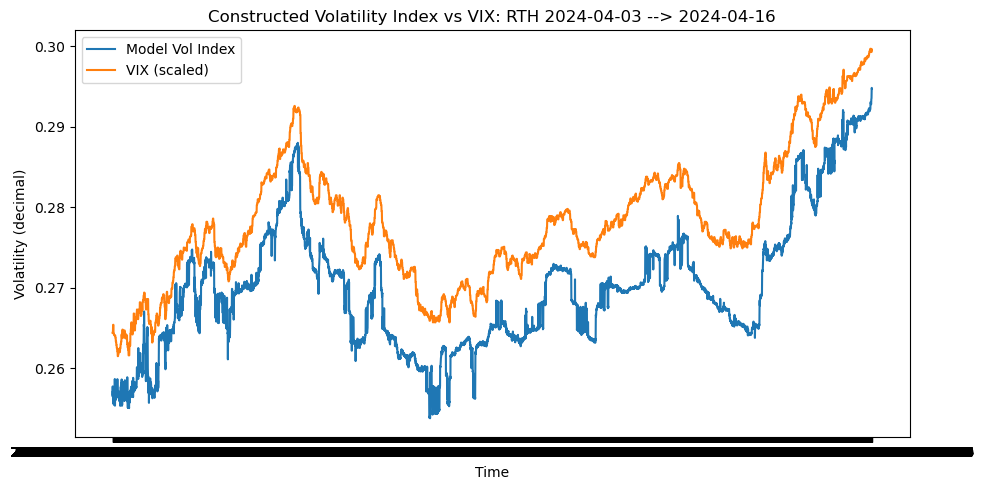

In [15]:
vol_ts = vol_index_df.merge(
    assets[["timestamp", "VIX"]],
    on="timestamp",
    how="left",
)

plt.figure(figsize=(10, 5))
plt.plot(vol_ts["timestamp"], vol_ts["vol_index"], label="Model Vol Index")
# VIX is usually in percent; divide by 100 to convert to decimal volatility
plt.plot(vol_ts["timestamp"], vol_ts["VIX"] / 100.0, label="VIX (scaled)")
# plt.axvline(event_date, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Volatility (decimal)")
plt.title("Constructed Volatility Index vs VIX: RTH 2024-04-03 --> 2024-04-16")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Time series of implied volatility at key strikes

In [16]:

def pick_key_strikes(group, atm_offset=200.0):
    """
    Given a group of options at one timestamp, pick ATM, OTM call, OTM put.
    """
    g = group.copy()
    S = g["SPX"].iloc[0]
    strikes = np.sort(g["strike"].unique())

    def nearest(k):
        idx = np.argmin(np.abs(strikes - k))
        return float(strikes[idx])

    atm_strike = nearest(S)
    k_call = nearest(S + atm_offset)
    k_put = nearest(S - atm_offset)
    return atm_strike, k_call, k_put


def build_key_iv_timeseries(df, target_days=30, maturity_window=2.0, atm_offset=200.0):
    records = []

    for t, group in df.groupby("timestamp"):
        g = group.copy()
        if g.empty:
            continue

        # maturity filter
        g["T_days"] = g["T"] * 365.0
        idx = (g["T_days"] - target_days).abs().idxmin()
        T_star = g.loc[idx, "T_days"]
        g = g[g["T_days"].between(T_star - maturity_window, T_star + maturity_window)]
        if g.empty:
            continue

        atm_strike, k_call, k_put = pick_key_strikes(g, atm_offset=atm_offset)

        iv_atm = g.loc[g["strike"] == atm_strike, "iv"].mean()
        iv_otm_call = g.loc[
            (g["strike"] == k_call) & (g["option_type"] == "C"),
            "iv",
        ].mean()
        iv_otm_put = g.loc[
            (g["strike"] == k_put) & (g["option_type"] == "P"),
            "iv",
        ].mean()

        records.append(
            {
                "timestamp": t,
                "iv_atm": iv_atm,
                "iv_otm_call": iv_otm_call,
                "iv_otm_put": iv_otm_put,
            }
        )

    out = pd.DataFrame(records).sort_values("timestamp")
    return out


iv_keys_df = build_key_iv_timeseries(
    data,
    target_days=target_maturity_days,
    maturity_window=2.0,
    atm_offset=200.0,
)

iv_keys_df.head()


,timestamp,iv_atm,iv_otm_call,iv_otm_put
0,2025-04-03 09:31:21.894935,0.259804,0.218859,0.292229
1,2025-04-03 09:31:24.901505,0.260466,0.217534,0.292288
2,2025-04-03 09:31:27.950585,0.259373,0.217794,0.291985
3,2025-04-03 09:31:30.955474,0.260060,0.218871,0.291553
4,2025-04-03 09:31:33.959339,0.258861,0.217871,0.291169


### 5.1 Plot key-strike IVs and SPX

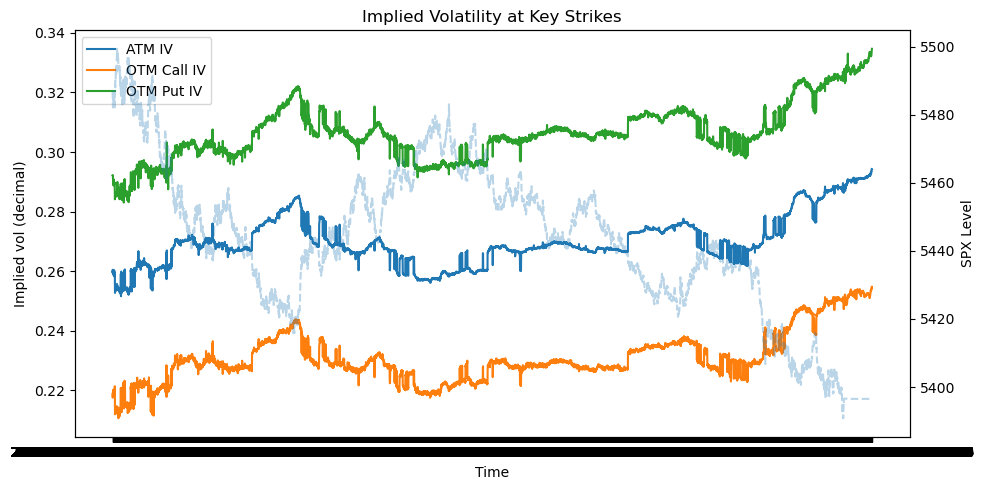

In [17]:

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(iv_keys_df["timestamp"], iv_keys_df["iv_atm"], label="ATM IV")
ax1.plot(iv_keys_df["timestamp"], iv_keys_df["iv_otm_call"], label="OTM Call IV")
ax1.plot(iv_keys_df["timestamp"], iv_keys_df["iv_otm_put"], label="OTM Put IV")
ax1.set_xlabel("Time")
ax1.set_ylabel("Implied vol (decimal)")
# ax1.axvline(event_date, linestyle="--")
ax1.legend(loc="upper left")
ax1.set_title("Implied Volatility at Key Strikes")

# Overlay SPX on a secondary axis
ax2 = ax1.twinx()
ax2.plot(assets["timestamp"], assets["SPX"], linestyle="--", alpha=0.3)
ax2.set_ylabel("SPX Level")

fig.tight_layout()
plt.show()
